<a href="https://colab.research.google.com/github/jfavian2011/Data-Science-Cohort-20/blob/main/Final_Copy_of_Census_Mapping_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mapping Populations in NM Mexico Counties and Clustering Medicare Provider Availability

CNM Ingenuity Data Science Cohort 20 Capstone project

Veronica Luzzi, Favian Jabalera, and Kimberly Butler

In [ ]:
import pandas as pd
import requests
import json
import urllib.parse as up
import matplotlib.pyplot as plt


### Making the specific census data available.  

In this case the data uploaded to huggingface is from the census bureau, but available here: https://bber.unm.edu/data/bberdb -The table used is S0101 Summary Age and Sex.csv from 2024.


In [ ]:
url = 'https://huggingface.co/datasets/vluzzi/BBER_NMcensus/resolve/main/S0101%20Summary%20Age%20and%20Sex.csv'
url

'https://huggingface.co/datasets/vluzzi/BBER_NMcensus/resolve/main/S0101%20Summary%20Age%20and%20Sex.csv'

### Read the file



In [ ]:
# Load the dataframe (using the URL from your notebook)

df = pd.read_csv(url, dtype="str")

df

,area,areatype,geographyname,period,periodtype,periodtypename,periodyear,stfips,totalpopulation_total_e,totalpopulation_total_m,...,summind_agedepratio_oldagedepratio_male_m,summind_agedepratio_oldagedepratio_female_e,summind_agedepratio_oldagedepratio_female_m,totpop_summind_mper100f_total_e,totpop_summind_mper100f_total_m,totpop_summind_mper100f_male_e,totpop_summind_mper100f_male_m,totpop_summind_mper100f_female_e,totpop_summind_mper100f_female_m,geo_id
0,000029,04,Luna County,00,60,ACS 5-year estimates,2024,35,25611,-6,...,-8,-8,-8,106.7,3.8,-8,-8,-8,-8,0500000US35029
1,000039,04,Rio Arriba County,00,60,ACS 5-year estimates,2024,35,40070,-6,...,-8,-8,-8,97.6,1,-8,-8,-8,-8,0500000US35039
2,000017,04,Grant County,00,60,ACS 5-year estimates,2024,35,27775,-6,...,-8,-8,-8,101.7,2,-8,-8,-8,-8,0500000US35017
3,000045,04,San Juan County,00,60,ACS 5-year estimates,2024,35,120942,-6,...,-8,-8,-8,97.3,0.4,-8,-8,-8,-8,0500000US35045
4,000019,04,Guadalupe County,00,60,ACS 5-year estimates,2024,35,4381,-6,...,-8,-8,-8,135.2,20.1,-8,-8,-8,-8,0500000US35019
5,000025,04,Lea County,00,60,ACS 5-year estimates,2024,35,73733,-6,...,-8,-8,-8,108,1.2,-8,-8,-8,-8,0500000US35025
6,000006,04,Cibola County,00,60,ACS 5-year estimates,2024,35,26845,-6,...,-8,-8,-8,98.4,3.5,-8,-8,-8,-8,0500000US35006
7,000031,04,Mckinley County,00,60,ACS 5-year estimates,2024,35,70431,-6,...,-8,-8,-8,92.7,0.7,-8,-8,-8,-8,0500000US35031
8,000057,04,Torrance County,00,60,ACS 5-year estimates,2024,35,15490,-6,...,-8,-8,-8,104,6.4,-8,-8,-8,-8,0500000US35057
9,000033,04,Mora County,00,60,ACS 5-year estimates,2024,35,4149,-6,...,-8,-8,-8,83.7,16.3,-8,-8,-8,-8,0500000US35033


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Columns: 237 entries, area to geo_id
dtypes: object(237)
memory usage: 61.2+ KB


In [ ]:
print(df)

      area areatype      geographyname period periodtype  \
0   000029       04        Luna County     00         60   
1   000039       04  Rio Arriba County     00         60   
2   000017       04       Grant County     00         60   
3   000045       04    San Juan County     00         60   
4   000019       04   Guadalupe County     00         60   
5   000025       04         Lea County     00         60   
6   000006       04      Cibola County     00         60   
7   000031       04    Mckinley County     00         60   
8   000057       04    Torrance County     00         60   
9   000033       04        Mora County     00         60   
10  000055       04        Taos County     00         60   
11  000047       04  San Miguel County     00         60   
12  000035       04       Otero County     00         60   
13  000003       04      Catron County     00         60   
14  000009       04       Curry County     00         60   
15  000023       04     Hidalgo County  

In [ ]:
# Force pandas to display all rows in the output window
import pandas as pd
pd.set_option('display.max_rows', None)

# View all columns and data types as a table
df.dtypes.to_frame(name='Data Type')

,Data Type
area,object
areatype,object
geographyname,object
period,object
periodtype,object
periodtypename,object
periodyear,object
stfips,object
totalpopulation_total_e,object
totalpopulation_total_m,object


### Optimizing data for mapping.

Created a smaller data frame. only containing the columns I am interested in.  In this case, focusing on total population/county, and total population older than 65 yo.  Also, calculating the %of individuals older than 65.

In [ ]:
import pandas as pd

# 1. Define base descriptive columns
base_cols = ['geo_id', 'area', 'geographyname', 'totalpopulation_total_e']

# 2. Define the specific age brackets you want to combine
age_65plus_total_cols = [
    'totpop_age_65to69_total_e',
    'totpop_age_70to74_total_e',
    'totpop_age_75to79_total_e',
    'totpop_age_80to84_total_e',
    'totpop_age_85plus_total_e'
]

# Generate the matching male and female column names automatically
age_65plus_male_cols = [col.replace('_total_e', '_male_e') for col in age_65plus_total_cols]
age_65plus_female_cols = [col.replace('_total_e', '_female_e') for col in age_65plus_total_cols]

# Pull everything out of your main dataframe
all_target_cols = base_cols + age_65plus_total_cols + age_65plus_male_cols + age_65plus_female_cols
working_df = df[all_target_cols].copy()


# 3. CRITICAL: Convert text data to numbers before adding
# Census data imports numbers as text strings. If we don't convert them,
# Python will concatenate strings (e.g. "10" + "20" becomes "1020") instead of adding them!
for col in all_target_cols:
    if col not in ['geo_id', 'area', 'geographyname']:
        working_df[col] = pd.to_numeric(working_df[col], errors='coerce')


# 4. Create your aggregated sums across rows using axis=1
working_df['totalpop_age_65plus_total_e'] = working_df[age_65plus_total_cols].sum(axis=1)
working_df['totalpop_age_65plus_male_e'] = working_df[age_65plus_male_cols].sum(axis=1)
working_df['totalpop_age_65plus_female_e'] = working_df[age_65plus_female_cols].sum(axis=1)


# 5. Create a final clean dataframe with intuitive, easy-to-map column names
final_columns = {
    'geo_id': 'geo_id',
    'area': 'area',
    'geographyname': 'county_name',
    'totalpopulation_total_e': 'total_population',
    'totalpop_age_65plus_total_e': 'total_65_plus',
    'totalpop_age_65plus_male_e': 'male_65_plus',
    'totalpop_age_65plus_female_e': 'female_65_plus'
}

clean_county_df = working_df[list(final_columns.keys())].rename(columns=final_columns).copy()



In [ ]:
# Recalculate your percentage target
clean_county_df['Percent65plus'] = (clean_county_df['total_65_plus'] / clean_county_df['total_population'] * 100).round(2)
clean_county_df

,geo_id,area,county_name,total_population,total_65_plus,male_65_plus,female_65_plus,Percent65plus
0,0500000US35029,000029,Luna County,25611,5330,2704,2626,20.81
1,0500000US35039,000039,Rio Arriba County,40070,8742,4065,4677,21.82
2,0500000US35017,000017,Grant County,27775,8419,4073,4346,30.31
3,0500000US35045,000045,San Juan County,120942,20461,9388,11073,16.92
4,0500000US35019,000019,Guadalupe County,4381,754,458,296,17.21
5,0500000US35025,000025,Lea County,73733,8378,3931,4447,11.36
6,0500000US35006,000006,Cibola County,26845,4881,2228,2653,18.18
7,0500000US35031,000031,Mckinley County,70431,9712,4033,5679,13.79
8,0500000US35057,000057,Torrance County,15490,3488,1803,1685,22.52
9,0500000US35033,000033,Mora County,4149,1411,634,777,34.01


In [ ]:
# Inspect your new clean 33-row dataframe
print("Dataframe shape:", clean_county_df.shape)
clean_county_df.head()

Dataframe shape: (33, 8)


,geo_id,area,county_name,total_population,total_65_plus,male_65_plus,female_65_plus,Percent65plus
0,0500000US35029,000029,Luna County,25611,5330,2704,2626,20.81
1,0500000US35039,000039,Rio Arriba County,40070,8742,4065,4677,21.82
2,0500000US35017,000017,Grant County,27775,8419,4073,4346,30.31
3,0500000US35045,000045,San Juan County,120942,20461,9388,11073,16.92
4,0500000US35019,000019,Guadalupe County,4381,754,458,296,17.21


### Creating a Bar Graph

In [ ]:
import plotly.express as px

# 1. Strip the word "County" from the county_name column
clean_county_df['county_name'] = clean_county_df['county_name'].str.replace(r'\s*County\s*', '', case=False, regex=True)

# 2. Filter the dataframe for counties that are 25% and up
high_aging_df = clean_county_df[clean_county_df['Percent65plus'] >= 25]
sorted_high_df = high_aging_df.sort_values(by='Percent65plus', ascending=True)

# 3. Build the horizontal bar chart
fig = px.bar(
    sorted_high_df,
    x='Percent65plus',
    y='county_name',
    orientation='h',
    title='Ranking of New Mexico Counties by Percentage of Population Aged 65+',
    labels={'Percent65plus': 'Population Aged 65+ (%)', 'county_name': 'County'},
    text_auto='.1f',
    color='Percent65plus',
    color_continuous_scale='YlOrRd'
)

# 4. Clean up the layout proportions and ADJUST FONT SIZES
fig.update_layout(
    height=800,
    title_font_size=22,           # Larger Chart Title

    # Increase the size of the axis titles (e.g., "County", "Population Aged 65+ (%)")
    xaxis_title_font_size=20,
    yaxis_title_font_size=20,

    # Increase the size of the percentages stamped on the inside/tips of the bars
    font_size=22
)

# Increase the size of the individual county names and x-axis numbers (Ticks)
fig.update_yaxes(tickfont=dict(size=18), dtick=1) #
fig.update_xaxes(tickfont=dict(size=14))

fig.show()

## Creating the working Dataframe

In [ ]:
clean_county_df.head(5)

,geo_id,area,county_name,total_population,total_65_plus,male_65_plus,female_65_plus,Percent65plus
0,0500000US35029,000029,Luna County,25611,5330,2704,2626,20.81
1,0500000US35039,000039,Rio Arriba County,40070,8742,4065,4677,21.82
2,0500000US35017,000017,Grant County,27775,8419,4073,4346,30.31
3,0500000US35045,000045,San Juan County,120942,20461,9388,11073,16.92
4,0500000US35019,000019,Guadalupe County,4381,754,458,296,17.21


In [ ]:
clean_county_df_back = clean_county_df.copy()
clean_county_df_back.head()

,geo_id,area,county_name,total_population,total_65_plus,male_65_plus,female_65_plus,Percent65plus
0,0500000US35029,000029,Luna County,25611,5330,2704,2626,20.81
1,0500000US35039,000039,Rio Arriba County,40070,8742,4065,4677,21.82
2,0500000US35017,000017,Grant County,27775,8419,4073,4346,30.31
3,0500000US35045,000045,San Juan County,120942,20461,9388,11073,16.92
4,0500000US35019,000019,Guadalupe County,4381,754,458,296,17.21


In [ ]:
clean_county_df = clean_county_df_back.copy()
clean_county_df.head()

,geo_id,area,county_name,total_population,total_65_plus,male_65_plus,female_65_plus,Percent65plus
0,0500000US35029,000029,Luna County,25611,5330,2704,2626,20.81
1,0500000US35039,000039,Rio Arriba County,40070,8742,4065,4677,21.82
2,0500000US35017,000017,Grant County,27775,8419,4073,4346,30.31
3,0500000US35045,000045,San Juan County,120942,20461,9388,11073,16.92
4,0500000US35019,000019,Guadalupe County,4381,754,458,296,17.21


In [ ]:
# Force geo_id to be a string and pad with leading zeros if any are missing
clean_county_df['geo_id'] = clean_county_df['geo_id'].astype(str).str.zfill(5)


In [ ]:
# working_df['geo_id'] = working_df['geo_id'].str.slice(-5)
clean_county_df['geo_id'] = clean_county_df['geo_id'].str.slice(-5)

In [ ]:
clean_county_df.head()

,geo_id,area,county_name,total_population,total_65_plus,male_65_plus,female_65_plus,Percent65plus
0,35029,000029,Luna County,25611,5330,2704,2626,20.81
1,35039,000039,Rio Arriba County,40070,8742,4065,4677,21.82
2,35017,000017,Grant County,27775,8419,4073,4346,30.31
3,35045,000045,San Juan County,120942,20461,9388,11073,16.92
4,35019,000019,Guadalupe County,4381,754,458,296,17.21


### Adding dataframe for providers

In [ ]:
import pandas as pd
import requests
import json
import urllib.parse as up

## Data source and information on the data

Note the address for the CMS data changes monthly, this link will allow the user to update the csv link https://data.cms.gov/provider-data/dataset/mj5m-pzi6#data-table

As this data is updated each month, the team used the June 1st updated data and hosted it on huggingface so it can be reliably available.

Additionally, the data dictionary is available online to allow review of the features in the table

In [ ]:
import pandas as pd

# 1. Load the dataset (Use your Google Drive path if you have it downloaded locally)
prov_url = "https://huggingface.co/datasets/rwcitek/medicare/resolve/main/DAC_NationalDownloadableFile.csv"
prov_df = pd.read_csv(prov_url, dtype="str")


In [ ]:
# 2. Filter for New Mexico first to drastically speed up processing
nm_all_df = prov_df[prov_df['State'].str.upper() == 'NM'].copy()
nm_all_df.head(5)


,NPI,Ind_PAC_ID,Ind_enrl_ID,Provider Last Name,Provider First Name,Provider Middle Name,suff,gndr,Cred,Med_sch,...,adr_ln_1,adr_ln_2,ln_2_sprs,City/Town,State,ZIP Code,Telephone Number,ind_assgn,grp_assgn,adrs_id
15596,1629459813,4183014012,I20220121000506,BENNET,MADELEINE,NaN,NaN,F,CSW,OTHER,...,NaN,NaN,NaN,COCHITI LAKE,NM,87083,5057964210,Y,M,NM87083XXXXCOXXXXXXXXXX00
15597,1275772600,2769828151,I20240307002752,WOLF,MELISSA,A,NaN,F,NaN,OTHER,...,NaN,NaN,NaN,ALBUQUERQUE,NM,87102,3232057088,Y,Y,NM87102XXXXALXXXXXXXXXX00
15598,1306340831,6406119304,I20250717001107,YARASHEVICH,ALEXI,NaN,NaN,M,NP,OTHER,...,NaN,NaN,NaN,ALBUQUERQUE,NM,87102,7147025145,Y,Y,NM87102XXXXALXXXXXXXXXX00
15599,1407232663,2567760523,I20190409000643,O'NEILL,GLORIA,NaN,NaN,F,NP,"UNIVERSITY OF MIAMI, LM MILLER SCHOOL OF MEDICINE",...,NaN,NaN,NaN,ALBUQUERQUE,NM,87102,3054509651,Y,M,NM87102XXXXALXXXXXXXXXX00
15600,1437118403,1254425101,I20250708000469,QUINN,RACHEL,ANN,NaN,F,MD,OTHER,...,NaN,NaN,NaN,ALBUQUERQUE,NM,87102,6463980527,Y,Y,NM87102XXXXALXXXXXXXXXX00


In [ ]:
nm_all_df['zip_5'] = nm_all_df['ZIP Code'].astype(str).str.extract(r'(\d+)', expand=False).str.zfill(5).str[:5]

In [ ]:
nm_all_df.head()

,NPI,Ind_PAC_ID,Ind_enrl_ID,Provider Last Name,Provider First Name,Provider Middle Name,suff,gndr,Cred,Med_sch,...,adr_ln_2,ln_2_sprs,City/Town,State,ZIP Code,Telephone Number,ind_assgn,grp_assgn,adrs_id,zip_5
15596,1629459813,4183014012,I20220121000506,BENNET,MADELEINE,NaN,NaN,F,CSW,OTHER,...,NaN,NaN,COCHITI LAKE,NM,87083,5057964210,Y,M,NM87083XXXXCOXXXXXXXXXX00,87083
15597,1275772600,2769828151,I20240307002752,WOLF,MELISSA,A,NaN,F,NaN,OTHER,...,NaN,NaN,ALBUQUERQUE,NM,87102,3232057088,Y,Y,NM87102XXXXALXXXXXXXXXX00,87102
15598,1306340831,6406119304,I20250717001107,YARASHEVICH,ALEXI,NaN,NaN,M,NP,OTHER,...,NaN,NaN,ALBUQUERQUE,NM,87102,7147025145,Y,Y,NM87102XXXXALXXXXXXXXXX00,87102
15599,1407232663,2567760523,I20190409000643,O'NEILL,GLORIA,NaN,NaN,F,NP,"UNIVERSITY OF MIAMI, LM MILLER SCHOOL OF MEDICINE",...,NaN,NaN,ALBUQUERQUE,NM,87102,3054509651,Y,M,NM87102XXXXALXXXXXXXXXX00,87102
15600,1437118403,1254425101,I20250708000469,QUINN,RACHEL,ANN,NaN,F,MD,OTHER,...,NaN,NaN,ALBUQUERQUE,NM,87102,6463980527,Y,Y,NM87102XXXXALXXXXXXXXXX00,87102


Next duplicate providers were removed.  It was noted in the data that many of the providers are duplicated.  Some providers may provide at multiple locations, which could be useful to retain, but others have multiple entries in the same zip code.  So we will use NPI and zip_5 to remove providers that are registered multiple times in the same zip code.

In [ ]:
nm_all_df = nm_all_df.drop_duplicates(subset=['NPI', 'zip_5'])

In [ ]:
#drop unwanted columns
nm_all_df = nm_all_df.drop(columns=[
    'NPI', 'Ind_PAC_ID', 'Ind_enrl_ID',
    'Provider Middle Name', 'suff', 'Med_sch',
    'Telephone Number', 'ind_assgn', 'grp_assgn',
    'adrs_id', 'Facility Name', 'org_pac_id',
    'num_org_mem', 'adr_ln_1', 'adr_ln_2', 'ln_2_sprs', 'Grd_yr',
    ])
nm_all_df.head(5)

,Provider Last Name,Provider First Name,gndr,Cred,pri_spec,sec_spec_1,sec_spec_2,sec_spec_3,sec_spec_4,sec_spec_all,Telehlth,City/Town,State,ZIP Code,zip_5
15596,BENNET,MADELEINE,F,CSW,CLINICAL SOCIAL WORKER,NaN,NaN,NaN,NaN,NaN,Y,COCHITI LAKE,NM,87083,87083
15597,WOLF,MELISSA,F,NaN,MENTAL HEALTH COUNSELOR,NaN,NaN,NaN,NaN,NaN,Y,ALBUQUERQUE,NM,87102,87102
15598,YARASHEVICH,ALEXI,M,NP,NURSE PRACTITIONER,NaN,NaN,NaN,NaN,NaN,Y,ALBUQUERQUE,NM,87102,87102
15599,O'NEILL,GLORIA,F,NP,NURSE PRACTITIONER,NaN,NaN,NaN,NaN,NaN,NaN,ALBUQUERQUE,NM,87102,87102
15600,QUINN,RACHEL,F,MD,FAMILY PRACTICE,NaN,NaN,NaN,NaN,NaN,Y,ALBUQUERQUE,NM,87102,87102


In [ ]:
#Define your target pattern
specialty_pattern = (
    r"GERIATRIC MEDICINE|"
    r"FAMILY PRACTICE"
)



In [ ]:
# List out all the primary and secondary specialty columns you want to inspect
specialty_columns = ['pri_spec', 'sec_spec_1', 'sec_spec_2', 'sec_spec_3', 'sec_spec_4', 'sec_spec_all']
specialty_columns


['pri_spec',
 'sec_spec_1',
 'sec_spec_2',
 'sec_spec_3',
 'sec_spec_4',
 'sec_spec_all']

In [ ]:
# --- THE CRITICAL MULTI-COLUMN MATCHING STEP ---
# This applies the text search to each specified column, producing a table of True/False flags.
# .any(axis=1) collapses it by saying "Keep row if ANY of the column flags are True".
multi_column_mask = nm_all_df[specialty_columns].apply(
    lambda col: col.str.contains(specialty_pattern, case=False, na=False)
).any(axis=1)
multi_column_mask


,0
15596,False
15597,False
15598,False
15599,False
15600,True
15601,False
15602,False
15603,False
15604,False
15605,False


In [ ]:
#Extract the rows using our combined mask
nm_filtered_providers = nm_all_df[multi_column_mask].copy()
nm_filtered_providers


,Provider Last Name,Provider First Name,gndr,Cred,pri_spec,sec_spec_1,sec_spec_2,sec_spec_3,sec_spec_4,sec_spec_all,Telehlth,City/Town,State,ZIP Code,zip_5
15600,QUINN,RACHEL,F,MD,FAMILY PRACTICE,NaN,NaN,NaN,NaN,NaN,Y,ALBUQUERQUE,NM,87102,87102
15660,STOLARCZYK,LISA,F,MD,FAMILY PRACTICE,NaN,NaN,NaN,NaN,NaN,Y,ALBUQUERQUE,NM,87110,87110
15661,YASIN,FARES,M,MD,FAMILY PRACTICE,NaN,NaN,NaN,NaN,NaN,NaN,ALBUQUERQUE,NM,87110,87110
15663,BANIKARIM,EFFAT,F,MD,FAMILY PRACTICE,NaN,NaN,NaN,NaN,NaN,NaN,ALBUQUERQUE,NM,87110,87110
15682,GALLEGOS,EMMANUEL,M,MD,EMERGENCY MEDICINE,FAMILY PRACTICE,NaN,NaN,NaN,FAMILY PRACTICE,NaN,ALBUQUERQUE,NM,87110,87110
15683,CHARLES SALDANA,ALEX,M,MD,FAMILY PRACTICE,NaN,NaN,NaN,NaN,NaN,NaN,ALBUQUERQUE,NM,87110,87110
15685,RHYMES,JILL,F,MD,INTERNAL MEDICINE,GERIATRIC MEDICINE,NaN,NaN,NaN,GERIATRIC MEDICINE,Y,ALBUQUERQUE,NM,87110,87110
15692,SAMES,THOMAS,M,MD,FAMILY PRACTICE,NaN,NaN,NaN,NaN,NaN,NaN,ALBUQUERQUE,NM,87110,87110
15693,ACOSTA,STEVEN,M,MD,INTERNAL MEDICINE,EMERGENCY MEDICINE,FAMILY PRACTICE,GENERAL PRACTICE,NaN,"EMERGENCY MEDICINE, FAMILY PRACTICE, GENERAL P...",NaN,ALBUQUERQUE,NM,87110,87110
15703,BRENNAN,MARY,F,MD,FAMILY PRACTICE,NaN,NaN,NaN,NaN,NaN,NaN,ALBUQUERQUE,NM,87110,87110


In [ ]:
# Verify results
print(f"Successfully isolated {nm_filtered_providers.shape[0]} providers checking across primary and secondary specialties.")

Successfully isolated 1182 providers checking across primary and secondary specialties.


In [ ]:
nm_filtered_providers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1182 entries, 15600 to 3356906
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Provider Last Name   1182 non-null   object
 1   Provider First Name  1182 non-null   object
 2   gndr                 1182 non-null   object
 3   Cred                 1176 non-null   object
 4   pri_spec             1182 non-null   object
 5   sec_spec_1           208 non-null    object
 6   sec_spec_2           31 non-null     object
 7   sec_spec_3           5 non-null      object
 8   sec_spec_4           1 non-null      object
 9   sec_spec_all         208 non-null    object
 10  Telehlth             303 non-null    object
 11  City/Town            1182 non-null   object
 12  State                1182 non-null   object
 13  ZIP Code             1182 non-null   object
 14  zip_5                1182 non-null   object
dtypes: object(15)
memory usage: 147.8+ KB


### Adding geo location to counties

In [ ]:
!pip install pgeocode

In [ ]:
import pgeocode

# Use 'Nominatim' instead of 'Geocoder'
nomi = pgeocode.Nominatim('us')



In [ ]:
import json
import folium
import geopandas as gpd

print("Fetching New Mexico county boundaries via GeoPandas...")
try:
    # Read a highly stable US County boundary map directly from the US Census TIGER shapefile server
    us_counties = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_20m.zip")

    # Filter immediately for New Mexico (State FIPS code is '35')
    nm_counties = us_counties[us_counties['STATEFP'] == '35'].copy()

    # Format the GEOID column to be explicitly a 5-digit string (matches your geo_id)
    nm_counties['GEOID'] = nm_counties['GEOID'].astype(str).str.zfill(5)

    # Convert the GeoPandas dataframe directly into a raw GeoJSON dictionary object
    nm_geojson = json.loads(nm_counties.to_json())
    print(f"Success! Captured and formatted boundary assets for all {len(nm_counties)} counties.")

except Exception as e:
    print(f"Alternative geographic fetch strategy failed: {e}")


# Initialize background map centered on New Mexico
nm_map = folium.Map(location=[34.5199, -105.8701], zoom_start=7)

# Add the Census Choropleth Layer
folium.Choropleth(
    geo_data=nm_geojson,                   # Your GeoPandas boundary object
    name='Aging Demographics (65+)',
    data=clean_county_df,                  # Processed DataFrame
    columns=['geo_id', 'Percent65plus'],   # Now both match '35001' style 5-digit strings
    key_on='feature.properties.GEOID',     # Tells Folium to link to the 5-digit id in the map file
    fill_color='YlOrRd',
    # fill_color='BuPu',
    fill_opacity=0.7,
    line_opacity=0.4,
    legend_name='Percentage of Population Age 65+ (%)'
).add_to(nm_map)


# Add layer control toggles
folium.LayerControl().add_to(nm_map)

# Display the map
nm_map

Fetching New Mexico county boundaries via GeoPandas...
Success! Captured and formatted boundary assets for all 33 counties.


In [ ]:
!pip install geopandas

### Merging both data frames

census data and providers data

In [ ]:
clean_county_df

,geo_id,area,county_name,total_population,total_65_plus,male_65_plus,female_65_plus,Percent65plus
0,35029,000029,Luna County,25611,5330,2704,2626,20.81
1,35039,000039,Rio Arriba County,40070,8742,4065,4677,21.82
2,35017,000017,Grant County,27775,8419,4073,4346,30.31
3,35045,000045,San Juan County,120942,20461,9388,11073,16.92
4,35019,000019,Guadalupe County,4381,754,458,296,17.21
5,35025,000025,Lea County,73733,8378,3931,4447,11.36
6,35006,000006,Cibola County,26845,4881,2228,2653,18.18
7,35031,000031,Mckinley County,70431,9712,4033,5679,13.79
8,35057,000057,Torrance County,15490,3488,1803,1685,22.52
9,35033,000033,Mora County,4149,1411,634,777,34.01


In [ ]:
# Make sure both dataframes use clean, title-case strings for the county join column
clean_county_df['County_Clean'] = clean_county_df['county_name'].str.replace(' County, New Mexico', '', case=False).str.strip().str.title()
clean_county_df


,geo_id,area,county_name,total_population,total_65_plus,male_65_plus,female_65_plus,Percent65plus,County_Clean
0,35029,000029,Luna County,25611,5330,2704,2626,20.81,Luna County
1,35039,000039,Rio Arriba County,40070,8742,4065,4677,21.82,Rio Arriba County
2,35017,000017,Grant County,27775,8419,4073,4346,30.31,Grant County
3,35045,000045,San Juan County,120942,20461,9388,11073,16.92,San Juan County
4,35019,000019,Guadalupe County,4381,754,458,296,17.21,Guadalupe County
5,35025,000025,Lea County,73733,8378,3931,4447,11.36,Lea County
6,35006,000006,Cibola County,26845,4881,2228,2653,18.18,Cibola County
7,35031,000031,Mckinley County,70431,9712,4033,5679,13.79,Mckinley County
8,35057,000057,Torrance County,15490,3488,1803,1685,22.52,Torrance County
9,35033,000033,Mora County,4149,1411,634,777,34.01,Mora County


In [ ]:
nm_filtered_providers.head(5)

,Provider Last Name,Provider First Name,gndr,Cred,pri_spec,sec_spec_1,sec_spec_2,sec_spec_3,sec_spec_4,sec_spec_all,Telehlth,City/Town,State,ZIP Code,zip_5
15600,QUINN,RACHEL,F,MD,FAMILY PRACTICE,NaN,NaN,NaN,NaN,NaN,Y,ALBUQUERQUE,NM,87102,87102
15660,STOLARCZYK,LISA,F,MD,FAMILY PRACTICE,NaN,NaN,NaN,NaN,NaN,Y,ALBUQUERQUE,NM,87110,87110
15661,YASIN,FARES,M,MD,FAMILY PRACTICE,NaN,NaN,NaN,NaN,NaN,NaN,ALBUQUERQUE,NM,87110,87110
15663,BANIKARIM,EFFAT,F,MD,FAMILY PRACTICE,NaN,NaN,NaN,NaN,NaN,NaN,ALBUQUERQUE,NM,87110,87110
15682,GALLEGOS,EMMANUEL,M,MD,EMERGENCY MEDICINE,FAMILY PRACTICE,NaN,NaN,NaN,FAMILY PRACTICE,NaN,ALBUQUERQUE,NM,87110,87110


In [ ]:
import pgeocode

# 1. Initialize the pgeocode engine for US postal codes
nomi = pgeocode.Nominatim('us')

# 2. Extract the clean 5-digit ZIP codes from your filtered providers
# (Using 'Zip Code' or whatever your exact column name is for ZIPs)
nm_filtered_providers['zip_5'] = nm_filtered_providers['ZIP Code'].str.slice(0, 5)

# 3. Perform the offline geocoding lookup
print("Mapping provider ZIP codes to official NM counties...")
geo_lookup = nomi.query_postal_code(nm_filtered_providers['zip_5'].tolist())

# 4. Create the missing 'County_Clean' column from the lookup results
nm_filtered_providers['County_Clean'] = geo_lookup['county_name'].values

# 5. Handle missing values just in case any ZIP codes didn't match the database
nm_filtered_providers['County_Clean'] = nm_filtered_providers['County_Clean'].fillna('Unknown')

# ==========================================
# NOW RUN YOUR STEP 2 AGGREGATION CODE
# ==========================================
# Group by county and count the number of rows (providers) in each
provider_counts = nm_filtered_providers.groupby('County_Clean').size().reset_index(name='provider_count')

# Ensure the county names are Title Case to match the census format
provider_counts['County_Clean'] = provider_counts['County_Clean'].str.strip().str.title()

# Quick look to confirm the aggregation worked
print(f"Aggregated data into {provider_counts.shape[0]} unique rows.")
provider_counts.head()

Mapping provider ZIP codes to official NM counties...
Aggregated data into 30 unique rows.


,County_Clean,provider_count
0,Bernalillo,415
1,Chaves,11
2,Cibola,29
3,Colfax,6
4,Curry,47


In [ ]:
# 1. Ensure the county names in your census dataframe are formatted cleanly
clean_county_df['County_Clean'] = clean_county_df['county_name'].str.replace(' County, New Mexico', '', case=False).str.strip().str.title()

# 2. Merge the provider summary counts into your master 33-row census table
clustering_df = pd.merge(clean_county_df, provider_counts, on='County_Clean', how='left')

# 3. Fill missing values (NaN) with 0 for counties that don't have any of these providers
clustering_df['provider_count'] = clustering_df['provider_count'].fillna(0).astype(int)

# 4. Standardize your supply metric by calculating providers per 10,000 seniors
clustering_df['Providers_Per_10k_Seniors'] = (
    (clustering_df['provider_count'] / clustering_df['total_65_plus']) * 10000
).round(2)

clustering_df['Providers_Per_tot_pop'] = (
    (clustering_df['provider_count'] / clustering_df['total_population'])).round(2)

# 5. Take a look at your complete machine learning feature matrix!
print("Master Feature Matrix Rows and Columns:", clustering_df.shape)
clustering_df[['County_Clean', 'Percent65plus', 'provider_count', 'Providers_Per_10k_Seniors']].head()
clustering_df

Master Feature Matrix Rows and Columns: (33, 12)


,geo_id,area,county_name,total_population,total_65_plus,male_65_plus,female_65_plus,Percent65plus,County_Clean,provider_count,Providers_Per_10k_Seniors,Providers_Per_tot_pop
0,35029,000029,Luna County,25611,5330,2704,2626,20.81,Luna County,0,0.0,0.0
1,35039,000039,Rio Arriba County,40070,8742,4065,4677,21.82,Rio Arriba County,0,0.0,0.0
2,35017,000017,Grant County,27775,8419,4073,4346,30.31,Grant County,0,0.0,0.0
3,35045,000045,San Juan County,120942,20461,9388,11073,16.92,San Juan County,0,0.0,0.0
4,35019,000019,Guadalupe County,4381,754,458,296,17.21,Guadalupe County,0,0.0,0.0
5,35025,000025,Lea County,73733,8378,3931,4447,11.36,Lea County,0,0.0,0.0
6,35006,000006,Cibola County,26845,4881,2228,2653,18.18,Cibola County,0,0.0,0.0
7,35031,000031,Mckinley County,70431,9712,4033,5679,13.79,Mckinley County,0,0.0,0.0
8,35057,000057,Torrance County,15490,3488,1803,1685,22.52,Torrance County,0,0.0,0.0
9,35033,000033,Mora County,4149,1411,634,777,34.01,Mora County,0,0.0,0.0


In [ ]:
print("--- Census County Names ---")
print(sorted(clean_county_df['County_Clean'].unique()[:5]))

print("\n--- Provider County Names ---")
print(sorted(provider_counts['County_Clean'].unique()[:5]))

--- Census County Names ---
['Grant County', 'Guadalupe County', 'Luna County', 'Rio Arriba County', 'San Juan County']

--- Provider County Names ---
['Bernalillo', 'Chaves', 'Cibola', 'Colfax', 'Curry']


### Cleaning and matching the dataframes

The clean_county_df had the word 'county' after each county name.  The joint did not work because the county names were different.

In [ ]:
# 1. Clean up the Census county names using your actual 'county_name' column
clean_county_df['County_Clean'] = (
    clean_county_df['county_name']        # Points to your existing 'county_name' column
    .str.replace(' County', '', case=False) # Strips out ' County' (e.g., 'Grant County' becomes 'Grant')
    .str.strip()
    .str.title()
    .str.replace('ñ', 'n', case=False)     # Ensures Doña Ana matches Dona Ana safely
)

# 2. Clean up the Provider county names to ensure identical string formatting
provider_counts['County_Clean'] = (
    provider_counts['County_Clean']
    .astype(str)
    .str.strip()
    .str.title()
    .str.replace('ñ', 'n', case=False)
)

# ==========================================
# DIAGNOSTIC CHECK: Print them again to be 100% sure they match
# ==========================================
print("--- Cleaned Census Counties ---")
print(sorted(clean_county_df['County_Clean'].unique()[:5]))

print("\n--- Cleaned Provider Counties ---")
print(sorted(provider_counts['County_Clean'].unique()[:5]))

# 3. Re-run the merge now that the keys are perfectly identical strings
clustering_df = pd.merge(clean_county_df, provider_counts, on='County_Clean', how='left')

# 4. Fill missing values (NaN) with 0 for counties that don't have any providers
clustering_df['provider_count'] = clustering_df['provider_count'].fillna(0).astype(int)

# 5. Calculate your standardized per-capita rate
clustering_df['Providers_Per_10k_Seniors'] = (
    (clustering_df['provider_count'] / clustering_df['total_65_plus']) * 10000
).round(2)

clustering_df['Providers_Per_tot_pop'] = (
    (clustering_df['provider_count'] / clustering_df['total_population']))

# 6. Take a look at your working matrix!
clustering_df[['County_Clean', 'provider_count', 'Providers_Per_10k_Seniors','Providers_Per_tot_pop']]
clustering_df

--- Cleaned Census Counties ---
['Grant', 'Guadalupe', 'Luna', 'Rio Arriba', 'San Juan']

--- Cleaned Provider Counties ---
['Bernalillo', 'Chaves', 'Cibola', 'Colfax', 'Curry']


,geo_id,area,county_name,total_population,total_65_plus,male_65_plus,female_65_plus,Percent65plus,County_Clean,provider_count,Providers_Per_10k_Seniors,Providers_Per_tot_pop
0,35029,000029,Luna County,25611,5330,2704,2626,20.81,Luna,7,13.13,0.000273
1,35039,000039,Rio Arriba County,40070,8742,4065,4677,21.82,Rio Arriba,23,26.31,0.000574
2,35017,000017,Grant County,27775,8419,4073,4346,30.31,Grant,15,17.82,0.000540
3,35045,000045,San Juan County,120942,20461,9388,11073,16.92,San Juan,63,30.79,0.000521
4,35019,000019,Guadalupe County,4381,754,458,296,17.21,Guadalupe,5,66.31,0.001141
5,35025,000025,Lea County,73733,8378,3931,4447,11.36,Lea,31,37.00,0.000420
6,35006,000006,Cibola County,26845,4881,2228,2653,18.18,Cibola,29,59.41,0.001080
7,35031,000031,Mckinley County,70431,9712,4033,5679,13.79,Mckinley,66,67.96,0.000937
8,35057,000057,Torrance County,15490,3488,1803,1685,22.52,Torrance,0,0.00,0.000000
9,35033,000033,Mora County,4149,1411,634,777,34.01,Mora,8,56.70,0.001928


## Running the unsupervised clustering

### Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Select your target features (Using Option B to include total population)
features = ['Percent65plus', 'Providers_Per_tot_pop', ]
X = clustering_df[features]

# 2. Initialize and apply the StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully! Matrix shape:", X_scaled.shape)

Features scaled successfully! Matrix shape: (33, 2)


### The features in X are related to each other.  Percent65plus is a % of total_population.  This will distort the cluster.  

We needed to find a way to prevent this distortion.

In [ ]:
X.head()

,Percent65plus,Providers_Per_tot_pop
0,20.81,0.000273
1,21.82,0.000574
2,30.31,0.000540
3,16.92,0.000521
4,17.21,0.001141


In [ ]:
X_scaled

array([[-2.60880135e-01, -6.72360661e-01],
       [-1.30830256e-01,  6.85370369e-02],
       [ 9.62361301e-01, -1.50985942e-02],
       [-7.61765313e-01, -6.22694552e-02],
       [-7.24424259e-01,  1.46641845e+00],
       [-1.47768346e+00, -3.09850896e-01],
       [-5.99524870e-01,  1.31606754e+00],
       [-1.16479118e+00,  9.63235685e-01],
       [-4.06966768e-02, -1.34585163e+00],
       [ 1.43878165e+00,  3.40538682e+00],
       [ 9.88113753e-01,  2.94844138e-01],
       [ 3.53315828e-01,  3.06066385e-01],
       [-6.80645092e-01, -4.86477868e-01],
       [ 3.18351023e+00, -1.34585163e+00],
       [-1.26908860e+00,  1.08525839e+00],
       [ 6.48883735e-02, -1.26296551e-01],
       [ 7.67930294e-01, -1.45992336e-01],
       [-7.45026220e-01, -2.03157027e-01],
       [ 1.08726069e+00,  2.38080506e-01],
       [-3.58739450e-01, -2.87081491e-01],
       [-2.29977194e-01,  6.31521427e-01],
       [ 4.57613256e-01,  9.55980263e-01],
       [-5.73772419e-01, -3.31553287e-01],
       [-1.

### Finding the Perfect 'K'

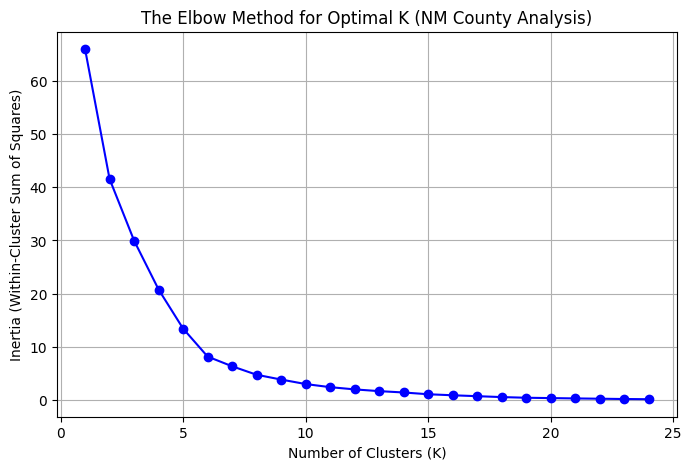

In [ ]:
# Calculate inertia for K values from 1 to 8
inertia = []
k_values = range(1, 25)

for k in k_values:
    # random_state=42 guarantees you get the exact same results every time you run it
    kmeans = KMeans(n_clusters=k, n_init=10)#to prevent from always getting same results random_state=42
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve using Matplotlib
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('The Elbow Method for Optimal K (NM County Analysis)')
plt.grid(True)
plt.show()

In [ ]:
# 1. Set K to 3 (or 4) based on your desired narrative focus
chosen_k = 5
kmeans_final10 = KMeans(n_clusters=chosen_k, n_init=30)

# 2. Fit and assign labels
clustering_df['Cluster_Label'] = kmeans_final10.fit_predict(X_scaled)

# 3. View the final county breakdown to see which counties landed where
for cluster in range(chosen_k):
    print(f"\n=== Counties in Cluster {cluster} ===")
    counties = clustering_df[clustering_df['Cluster_Label'] == cluster]['County_Clean'].tolist()
    print(counties)


=== Counties in Cluster 0 ===
['Luna', 'Rio Arriba', 'San Juan', 'Lea', 'Torrance', 'Otero', 'Hidalgo', 'Dona Ana', 'Sandoval', 'Los Alamos', 'Roosevelt', 'De Baca', 'Union', 'Valencia', 'Harding', 'Bernalillo', 'Chaves', 'Eddy']

=== Counties in Cluster 1 ===
['Grant', 'Taos', 'San Miguel', 'Colfax', 'Lincoln', 'Quay', 'Sierra', 'Santa Fe']

=== Counties in Cluster 2 ===
['Guadalupe', 'Cibola', 'Mckinley', 'Curry', 'Socorro']

=== Counties in Cluster 3 ===
['Catron']

=== Counties in Cluster 4 ===
['Mora']


### PCA vs 2D plot of Kmeans

Because we only have 2 dimensions, plotting the relationships using PCA vs plotting a 2D graph directly should yield similar graphs.  The PCA built below will help us visualize 2D if we decide to add more features in the future.

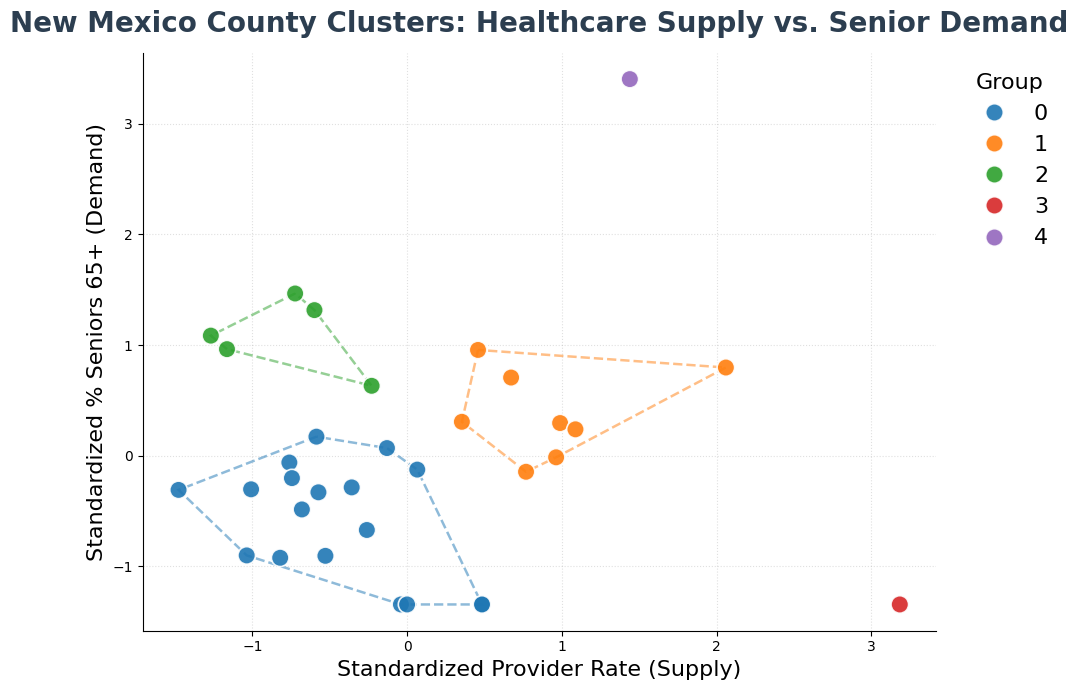

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon
import numpy as np

# 1. Use your raw, scaled 2-feature matrix directly (No PCA!)
# Column 0 = Providers_Per_10k_Seniors, Column 1 = Percent65plus
X_plot = X_scaled

labels = kmeans_final10.labels_

plt.figure(figsize=(10, 7), facecolor='white')
ax = plt.gca()

# 2. Plot the original features
sns.scatterplot(
    x=X_plot[:, 0],
    y=X_plot[:, 1],
    hue=labels,
    s=160,
    palette='tab10',
    legend='full',
    alpha=0.9,
    edgecolor='white',
    linewidth=1.2,
    zorder=3
)

# 3. Draw the polygon perimeters around the true feature boundaries
unique_labels = np.unique(labels)
colors = sns.color_palette('tab10', len(unique_labels))

for label in unique_labels:
    cluster_points = X_plot[labels == label]

    if len(cluster_points) >= 3:
        hull = ConvexHull(cluster_points)
        polygon = Polygon(
            cluster_points[hull.vertices],
            closed=True,
            fill=False,
            edgecolor=colors[label],
            linewidth=1.8,
            linestyle='--',
            alpha=0.5,
            zorder=2
        )
        ax.add_patch(polygon)

# 4. Use real-world, highly readable labels for your presentation slide!
plt.title('New Mexico County Clusters: Healthcare Supply vs. Senior Demand',
          fontsize=20, pad=15, fontweight='bold', color='#2c3e50')
plt.xlabel('Standardized Provider Rate (Supply)', fontsize=16, color='black')
plt.ylabel('Standardized % Seniors 65+ (Demand)', fontsize=16, color='black')

plt.legend(title='Group', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=16, title_fontsize=16)
plt.grid(True, linestyle=':', alpha=0.3, color='#999999', zorder=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('kmeans_2d_clusters.png', dpi=300)
plt.show()

In [ ]:
kmeans_final10.labels_

array([0, 0, 1, 0, 2, 0, 2, 2, 0, 4, 1, 1, 0, 3, 2, 0, 1, 0, 1, 0, 2, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1], dtype=int32)

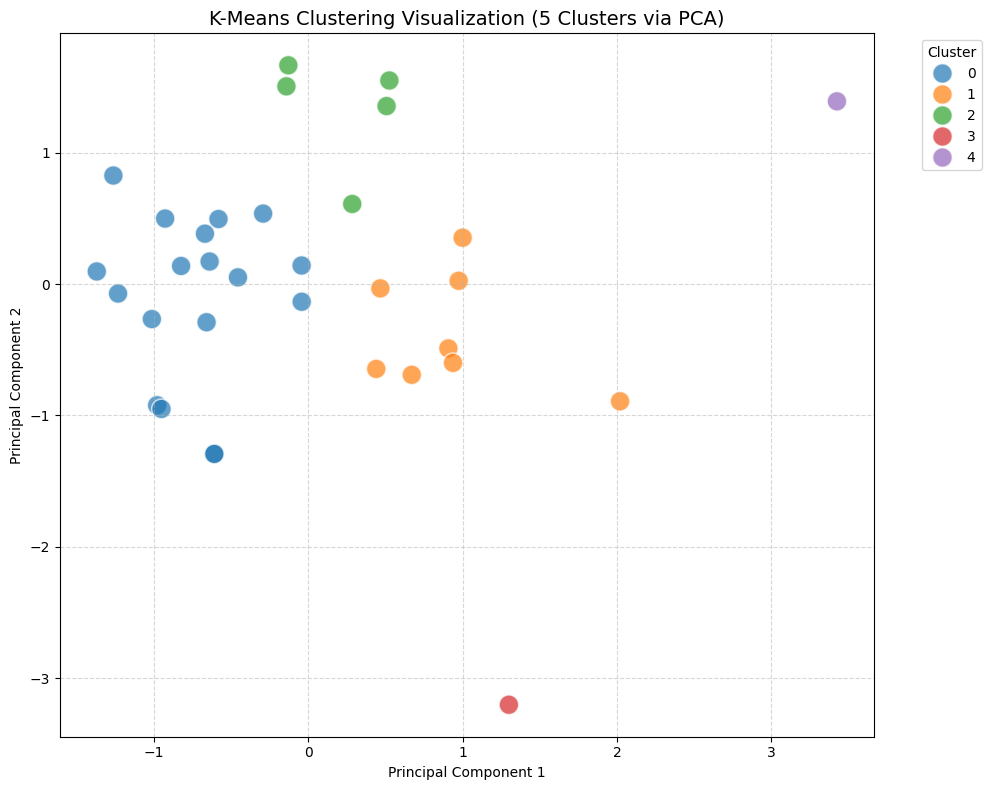

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Reduce your data to 2 dimensions using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled) # Use your scaled data here

# 2. Get the cluster predictions
labels = kmeans_final10.labels_

# 3. Create the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels,
    s=200,
    palette='tab10', # 'tab10' has exactly 10 distinct colors
    legend='full',
    alpha=0.7
)

# 4. Add clear titles and labels
plt.title('K-Means Clustering Visualization (5 Clusters via PCA)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('kmeans.pca.png')
plt.show()

### Adding polygons

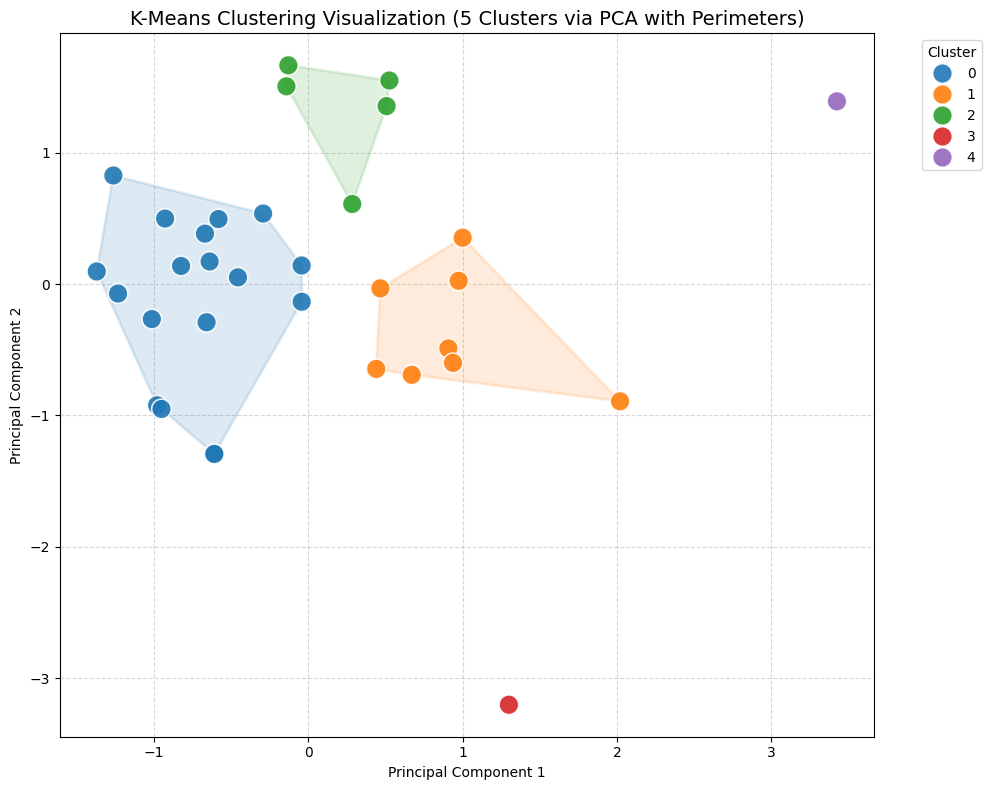

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull
import numpy as np
from matplotlib.patches import Polygon

# 1. Reduce your data to 2 dimensions using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled) # Use your scaled data here

# 2. Get the cluster predictions
labels = kmeans_final10.labels_

# 3. Create the scatter plot
plt.figure(figsize=(10, 8))
ax = plt.gca() # Get the current axes object to add the polygons onto

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels,
    s=200,
    palette='tab10', # 'tab10' has exactly 10 distinct colors
    legend='full',
    alpha=0.9, # Higher opacity for the scatter dots
    zorder=3    # Forces dots to sit cleanly on top of the shaded perimeters
)

# ==========================================
# NEW: DRAW POLYGON PERIMETERS FOR EACH CLUSTER
# ==========================================
# Get the unique colors assigned by seaborn to keep the line matching the dot color
unique_labels = np.unique(labels)
colors = sns.color_palette('tab10', len(unique_labels))

for label in unique_labels:
    # Filter out only the PCA points belonging to the current cluster
    cluster_points = X_pca[labels == label]

    # ConvexHull needs at least 3 points to form a polygon surface area
    if len(cluster_points) >= 3:
        # Calculate the outer bounding coordinates
        hull = ConvexHull(cluster_points)

        # Order the outer points sequentially so the polygon draws correctly
        hull_points = cluster_points[hull.vertices]

        # Create a shaded polygon with matching cluster line colors
        polygon = Polygon(
            hull_points,
            closed=True,
            facecolor=colors[label],
            edgecolor=colors[label],
            alpha=0.15,          # Subtle tint shading inside the boundary
            linewidth=2,          # Clear perimeter outline
            linestyle='-',
            zorder=2             # Sits below points but above grid lines
        )
        ax.add_patch(polygon)

# 4. Add clear titles and labels
plt.title('K-Means Clustering Visualization (5 Clusters via PCA with Perimeters)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5, zorder=1)

plt.tight_layout()
plt.savefig('kmeans.pca.png', dpi=300) # Added dpi=300 for slide-deck clarity
plt.show()

In [ ]:
total_variance = pca.explained_variance_ratio_.sum()
print(f"The 2D plot explains {total_variance * 100:.1f}% of the data's variance.")

The 2D plot explains 100.0% of the data's variance.


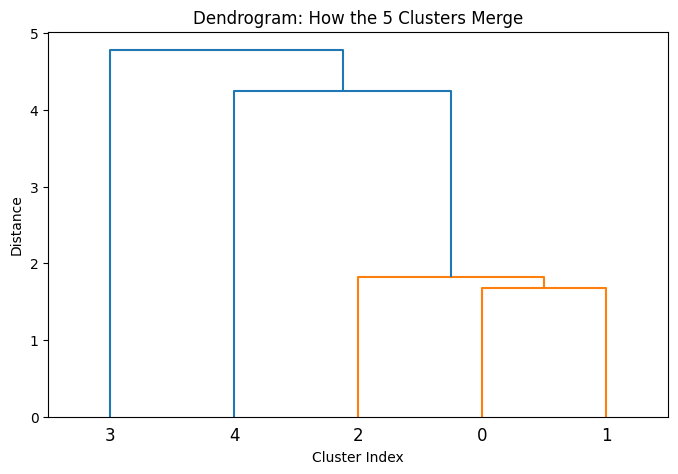

In [ ]:
import scipy.cluster.hierarchy as sch

# Calculate the centers (centroids) of your 10 clusters
centroids = kmeans_final10.cluster_centers_

# Plot a dendrogram to see how the 10 clusters group together
plt.figure(figsize=(8, 5))
dendrogram = sch.dendrogram(sch.linkage(centroids, method='ward'))
plt.title('Dendrogram: How the 5 Clusters Merge')
plt.xlabel('Cluster Index')
plt.ylabel('Distance')
plt.show()

### Adding a line to the dendogram

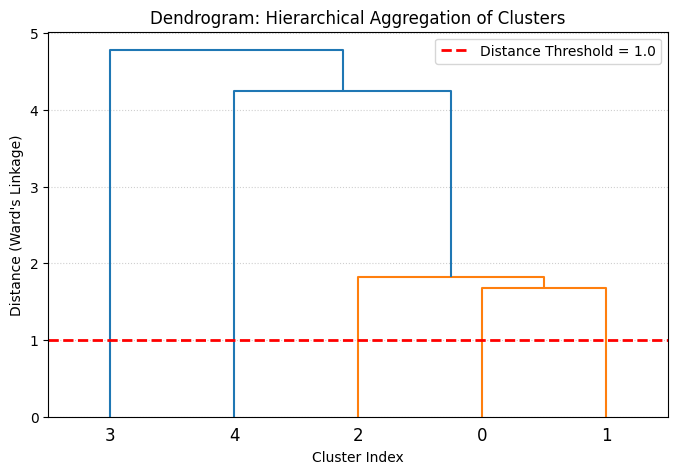

In [ ]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

# Calculate the centers (centroids) of your 10 clusters
centroids = kmeans_final10.cluster_centers_

# Plot a dendrogram to see how the 10 clusters group together
plt.figure(figsize=(8, 5))

# Generate the dendrogram
dendrogram = sch.dendrogram(sch.linkage(centroids, method='ward'))

# ==========================================
# NEW: ADD THE DASHED THRESHOLD LINE AT DISTANCE = 1
# ==========================================
plt.axhline(y=1.0, color='r', linestyle='--', linewidth=2, label='Distance Threshold = 1.0')

plt.title('Dendrogram: Hierarchical Aggregation of Clusters')
plt.xlabel('Cluster Index')
plt.ylabel('Distance (Ward\'s Linkage)')
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.savefig('dendo.pca.png', dpi=300)
plt.show()

### Adding the Providers_per_Senior data to the legend

### Visualizing the cluster on a NM map

In [ ]:
import numpy as np
import folium
from folium.features import DivIcon
from sklearn.cluster import KMeans

# =====================================================================
# 1. RUN THE CLUSTERING AND LABEL PROFILING
# =====================================================================
chosen_k = 5
kmeans_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)

# Fit and assign raw mathematical labels (0, 1, 2, 3)
clustering_df['Cluster_Label'] = kmeans_final.fit_predict(X_scaled)

# Calculate the mean provider rate for each cluster to inject into the map
cluster_means = clustering_df.groupby('Cluster_Label')['Providers_Per_10k_Seniors'].mean().to_dict()

# Map the actual provider rate back to the dataframe as a new feature column
# This allows Folium's color scale to reflect the true numerical separation
clustering_df['Cluster_Mean_Rate'] = clustering_df['Cluster_Label'].map(cluster_means)


# =====================================================================
# 2. INITIALIZE MAP & ADD CHOROPLETH WITH EXPERT LEGEND
# =====================================================================
cluster_map = folium.Map(location=[34.5199, -105.8701], zoom_start=7, tiles="CartoDB positron")

# Build a dynamically generated string showing the exact range for your legend
min_rate = round(clustering_df['Providers_Per_10k_Seniors'].min(), 1)
max_rate = round(clustering_df['Providers_Per_10k_Seniors'].max(), 1)

folium.Choropleth(
    geo_data=nm_geojson,
    name='Healthcare Access Clusters',
    data=clustering_df,
    columns=['geo_id', 'Cluster_Mean_Rate'], # Colors the map by the cluster's average rate
    key_on='feature.properties.GEOID',
    fill_color='BuPu',                     # Smooth color gradient matching your first map
    fill_opacity=0.7,
    line_opacity=0.4,
    # This directly updates your map legend text with the metric context:
    legend_name=f'Cluster Average Provider Availability (State Range: {min_rate} to {max_rate} Providers / 10k Seniors)'
).add_to(cluster_map)


# =====================================================================
# 3. ADD OPTION 1 PERMANENT COUNTY TEXT LABELS
# =====================================================================
for _, row in nm_counties.iterrows():
    centroid = row['geometry'].centroid
    lat, lon = centroid.y, centroid.x
    county_name = row['NAME'].replace(' County', '').strip()

    # Extract this specific county's cluster label to display next to the name if desired
    # (Optional: adds the cluster identifier directly below the county name text)
    matching_rows = clustering_df[clustering_df['geo_id'] == row['GEOID']]
    if not matching_rows.empty:
        c_num = matching_rows['Cluster_Label'].values[0]
        label_text = f"{county_name}<br><span style='font-size: 7pt; font-weight: normal; color: #555;'>C{c_num}</span>"
    else:
        label_text = county_name

    folium.Marker(
        location=[lat, lon],
        icon=DivIcon(
            icon_size=(150, 40),
            icon_anchor=(75, 20),
            html=f"""
                <div style="
                    font-size: 9pt;
                    font-weight: bold;
                    color: #2c3e50;
                    text-shadow: -1px -1px 0 #fff, 1px -1px 0 #fff, -1px 1px 0 #fff, 1px 1px 0 #fff;
                    text-align: center;
                    line-height: 1.1;
                ">
                    {label_text}
                </div>
            """
        )
    ).add_to(cluster_map)

# Add layer control and display map
folium.LayerControl().add_to(cluster_map)
cluster_map

### Colors match the number of clusters

In [ ]:
import numpy as np
import folium
from folium.features import DivIcon
from sklearn.cluster import KMeans

# =====================================================================
# 1. RUN THE CLUSTERING AND LABEL PROFILING
# =====================================================================
chosen_k = 5
kmeans_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)

# Fit and assign raw mathematical labels (0, 1, 2, 3, 4)
clustering_df['Cluster_Label'] = kmeans_final.fit_predict(X_scaled)

# Calculate the mean provider rate for each cluster to inject into text labels
cluster_means = clustering_df.groupby('Cluster_Label')['Providers_Per_10k_Seniors'].mean().to_dict()


# =====================================================================
# 2. INITIALIZE MAP & ADD CHOROPLETH WITH CATEGORICAL BINS
# =====================================================================
cluster_map = folium.Map(location=[34.5199, -105.8701], zoom_start=7, tiles="CartoDB positron")

# CRITICAL FIX: Define explicit bin edges around our cluster integers (0, 1, 2, 3, 4)
# This forces the 'BuPu' color palette to split into 5 perfectly separate, discrete colors.
categorical_bins = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]

folium.Choropleth(
    geo_data=nm_geojson,
    name='Healthcare Access Clusters',
    data=clustering_df,
    columns=['geo_id', 'Cluster_Label'],    # FIX: Color directly by the discrete group integer
    key_on='feature.properties.GEOID',
    fill_color='BuPu',                     # Retaining your preferred Blue-Purple scheme
    fill_opacity=0.8,
    line_opacity=0.4,
    bins=categorical_bins,                  # FIX: Forces 5 unique color steps with no overlapping bins
    legend_name='Healthcare Access Profile: Distinct Groups (C0 to C4)'
).add_to(cluster_map)


# =====================================================================
# 3. ADD OPTION 1 PERMANENT COUNTY TEXT LABELS WITH VALUE CONTEXT
# =====================================================================
for _, row in nm_counties.iterrows():
    centroid = row['geometry'].centroid
    lat, lon = centroid.y, centroid.x
    county_name = row['NAME'].replace(' County', '').strip()

    matching_rows = clustering_df[clustering_df['geo_id'] == row['GEOID']]
    if not matching_rows.empty:
        c_num = matching_rows['Cluster_Label'].values[0]
        c_rate = round(cluster_means[c_num], 1)
        # Displays the cluster number AND its specific average rate right on the county
        label_text = f"{county_name}<br><span style='font-size: 7.5pt; font-weight: normal; color: #444;'>C{c_num}"
    else:
        label_text = county_name

    folium.Marker(
        location=[lat, lon],
        icon=DivIcon(
            icon_size=(150, 45),
            icon_anchor=(75, 22),
            html=f"""
                <div style="
                    font-size: 9pt;
                    font-weight: bold;
                    color: #2c3e50;
                    text-shadow: -1px -1px 0 #fff, 1px -1px 0 #fff, -1px 1px 0 #fff, 1px 1px 0 #fff;
                    text-align: center;
                    line-height: 1.1;
                ">
                    {label_text}
                </div>
            """
        )
    ).add_to(cluster_map)

# Add layer control and display map
folium.LayerControl().add_to(cluster_map)
cluster_map